<a href="https://colab.research.google.com/github/aiska28/Data-Maining/blob/main/K_Means_Clustering_pada_Data_Kelas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [17]:
from google.colab import files
files.upload()

Saving Jobsheet_1.csv to Jobsheet_1.csv


{'Jobsheet_1.csv': b'Name ,Tempat Lahir ,Tanggal Lahir,Usia (Tahun),Jenis Kelamin,Alamat,Kota Domisili,Jenis Kendaraan,BBM Perbulan,IPK,Hobi,Tinggi Badan (cm),Berat Badan (kg),Jam Belajar,Rata-rata Tidur,Zodiak\r\nAhmad Rafi Hamdi,Lumajang,12-07-2005,21,Laki-Laki,jl. Kenanga,Malang,Motor,70.000,3.38,Sepak Bola,165,57,5,5,Gemini\r\nAhnaf Rifqi,Malang,21-05-2005,21,Laki-Laki,jl.Anggrek,Malang,Motor,45.000,3.60,Bermain Musik,175,67,5,5,Gemini\r\nAilsa Sahda Garizah,Kediri,26-03-2006,20,Perempuan,jl.Matahari,Malang,Motor,37.000,3.80,Membaca,154,55,7,7,Aries\r\nAiska Oca Amalia,Kediri,28-04-2005,21,Perempuan,jl.Lily,Malang,Motor,30.000,3.73,Menoton Film,155,50,6,8,Taurus\r\nAlyfa Zahra Qurrota Aini,Malang,17-01-2006,20,Perempuan,jl.Melati,Malang,Motor,50.000,3.83,Mendengarkan Musik,157,48,6,8,Capricon\r\nAndrian Sheva Azhar Faizal,Malang,23-09-2005,21,Laki-Laki,jl.Mawar,Malang,Motor,65.000,3.63,Sepak Bola,160,60,8,4,Libra\r\nAnindya Naura Putri Azahra,Ponorogo,10-05-2007,19,Perempuan,jl.Has

In [19]:
df = pd.read_csv('Jobsheet_1.csv')
df.head()

,Name,Tempat Lahir,Tanggal Lahir,Usia (Tahun),Jenis Kelamin,Alamat,Kota Domisili,Jenis Kendaraan,BBM Perbulan,IPK,Hobi,Tinggi Badan (cm),Berat Badan (kg),Jam Belajar,Rata-rata Tidur,Zodiak
0,Ahmad Rafi Hamdi,Lumajang,12-07-2005,21,Laki-Laki,jl. Kenanga,Malang,Motor,70.0,3.38,Sepak Bola,165,57,5,5,Gemini
1,Ahnaf Rifqi,Malang,21-05-2005,21,Laki-Laki,jl.Anggrek,Malang,Motor,45.0,3.60,Bermain Musik,175,67,5,5,Gemini
2,Ailsa Sahda Garizah,Kediri,26-03-2006,20,Perempuan,jl.Matahari,Malang,Motor,37.0,3.80,Membaca,154,55,7,7,Aries
3,Aiska Oca Amalia,Kediri,28-04-2005,21,Perempuan,jl.Lily,Malang,Motor,30.0,3.73,Menoton Film,155,50,6,8,Taurus
4,Alyfa Zahra Qurrota Aini,Malang,17-01-2006,20,Perempuan,jl.Melati,Malang,Motor,50.0,3.83,Mendengarkan Musik,157,48,6,8,Capricon


In [21]:
X_kelas = df.select_dtypes(include=['int64', 'float64'])

print(X_kelas.head())
print(X_kelas.dtypes)

   Usia (Tahun)  BBM Perbulan   IPK  Tinggi Badan (cm)  Berat Badan (kg)  \
0            21          70.0  3.38                165                57   
1            21          45.0  3.60                175                67   
2            20          37.0  3.80                154                55   
3            21          30.0  3.73                155                50   
4            20          50.0  3.83                157                48   

   Jam Belajar  Rata-rata Tidur  
0            5                5  
1            5                5  
2            7                7  
3            6                8  
4            6                8  
Usia (Tahun)           int64
BBM Perbulan         float64
IPK                  float64
Tinggi Badan (cm)      int64
Berat Badan (kg)       int64
Jam Belajar            int64
Rata-rata Tidur        int64
dtype: object


In [22]:
# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kelas)

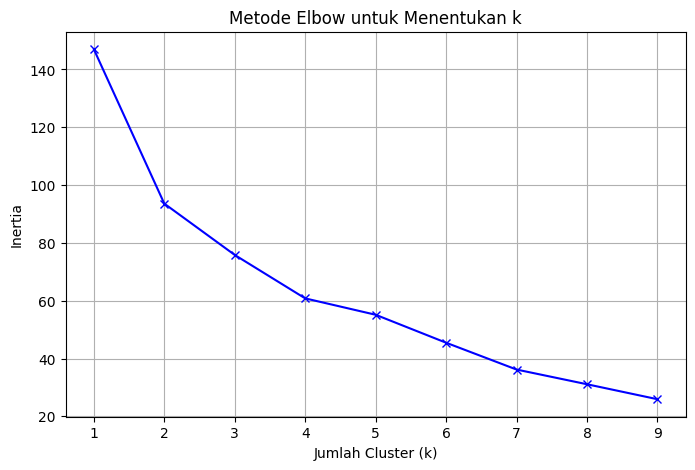

In [24]:
# Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot hasil elbow
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan k')
plt.grid(True)
plt.show()

In [26]:
# Buat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Lihat hasil clustering
print(df.head())

                      Name  Tempat Lahir  Tanggal Lahir  Usia (Tahun)  \
0          Ahmad Rafi Hamdi      Lumajang    12-07-2005            21   
1               Ahnaf Rifqi        Malang    21-05-2005            21   
2       Ailsa Sahda Garizah        Kediri    26-03-2006            20   
3          Aiska Oca Amalia        Kediri    28-04-2005            21   
4  Alyfa Zahra Qurrota Aini        Malang    17-01-2006            20   

  Jenis Kelamin       Alamat Kota Domisili Jenis Kendaraan  BBM Perbulan  \
0     Laki-Laki  jl. Kenanga        Malang           Motor          70.0   
1     Laki-Laki   jl.Anggrek        Malang           Motor          45.0   
2     Perempuan  jl.Matahari        Malang           Motor          37.0   
3     Perempuan      jl.Lily        Malang           Motor          30.0   
4     Perempuan    jl.Melati        Malang           Motor          50.0   

    IPK                Hobi  Tinggi Badan (cm)  Berat Badan (kg)  Jam Belajar  \
0  3.38          Sepak 

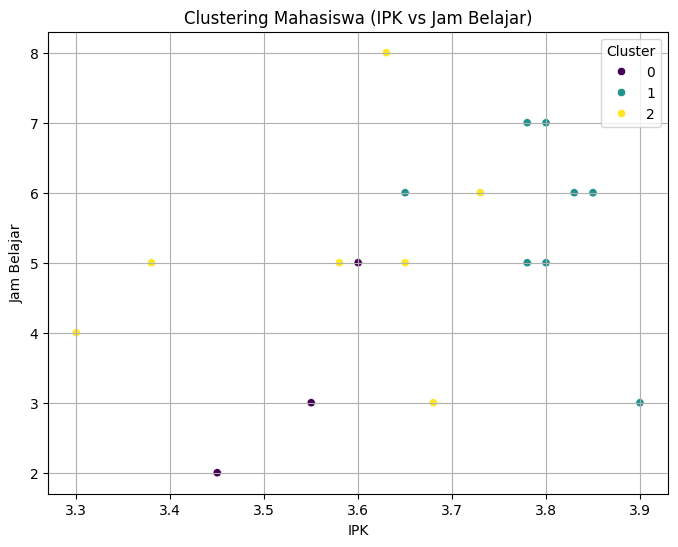

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['IPK'],
    y=df['Jam Belajar'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title('Clustering Mahasiswa (IPK vs Jam Belajar)')
plt.xlabel('IPK')
plt.ylabel('Jam Belajar')
plt.grid(True)
plt.show()


Silhouette Score: 0.267
Inertia (k=3): 76.321


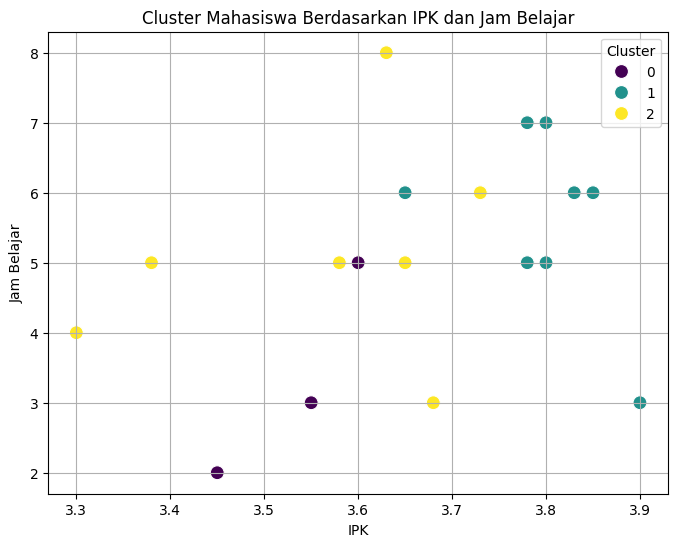

In [28]:
# 7a. Hitung Silhouette Score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.3f}")

# 7b. Tampilkan inertia akhir
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

# Step 8 — Visualisasi hasil clustering (2 fitur: IPK vs Jam Belajar)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['IPK'],
    y=df['Jam Belajar'],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)

plt.title('Cluster Mahasiswa Berdasarkan IPK dan Jam Belajar')
plt.xlabel('IPK')
plt.ylabel('Jam Belajar')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()